In [47]:
import pandas as pd
from datasets.loader import load_files, load_npy_file, load_json_file
from evaluation.visualization import plot_histories
import matplotlib.pyplot as plt
from datasets.paths import ProjectPaths
import math


In [23]:
pd.set_option("display.max_columns", None)


In [24]:
paths = ProjectPaths()


In [25]:
histories = load_files(paths.models_dir, "history.npy", load_npy_file)
print(histories.keys())


dict_keys(['bilstm_mean_cosine_data', 'lstm_last_manhattan', 'lstm_mean_cosine', 'lstm_mean_manhattan'])


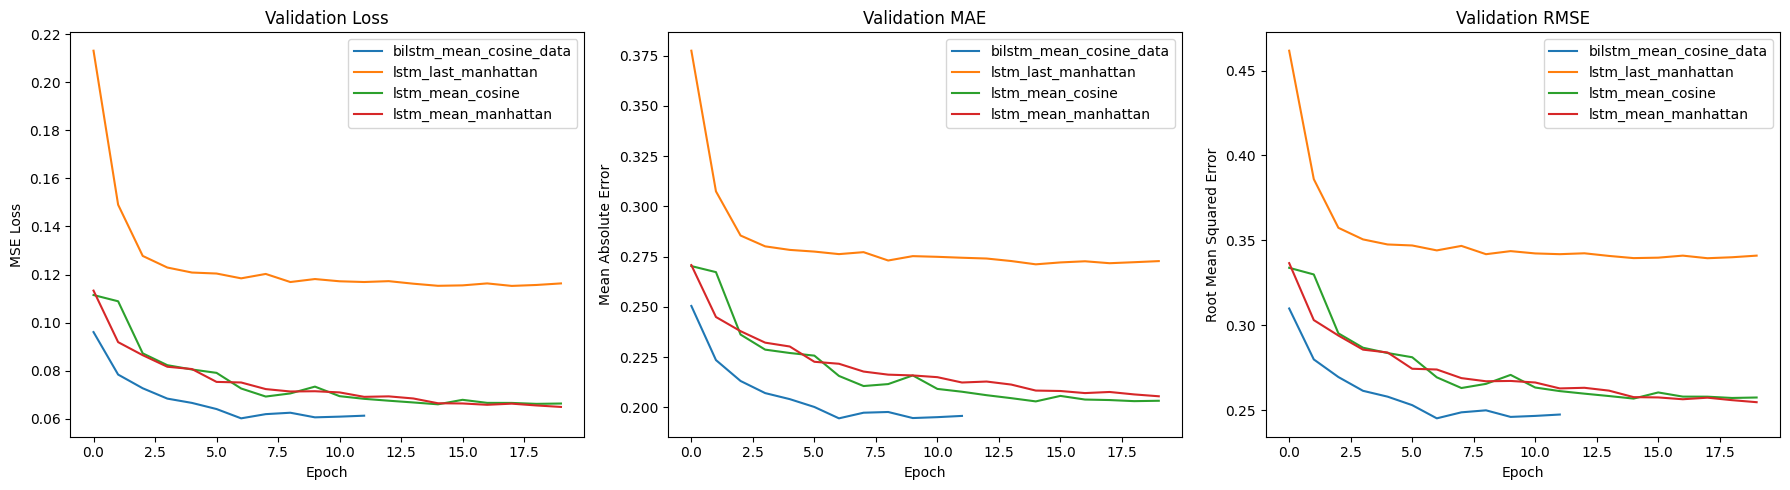

In [26]:
plot_histories(histories, paths.models_dir)


In [27]:
metrics = load_files(paths.models_dir, "metrics.json", load_json_file)
print(len(metrics))


4


In [28]:
df = pd.DataFrame(metrics.values())
display(df)


,name,hidden_dim,embedding_dim,pooling,similarity,bidirectional,mlp_layers,concat_features,mlp_dropout,lstm_dropout,sequence_length,data_augmentation,train_time_s,train_loss,train_mae,val_loss,val_mae,test_pearson,test_spearman,test_mse,test_mae,test_rmse,test_bias,test_r2,calibration_pearson,calibration_spearman,calibration_mse,calibration_mae,calibration_rmse,calibration_bias,calibration_r2
0,bilstm_mean_cosine,64,400,mean,cosine,True,[16],[diff],0.4,0.3,27,True,3494.175898,0.014121,0.094534,0.060112,0.194566,0.669886,0.663131,0.064909,0.199147,0.254773,-0.113582,0.301661,0.676829,0.662148,0.050709,0.174617,0.225187,0.009353,0.454435
1,lstm_last_manhattan,64,400,last,manhattan,False,"[64, 32]",[diff],0.4,0.3,26,False,987.804622,0.075717,0.219848,0.115253,0.271714,0.391634,0.396877,0.117226,0.268360,0.342383,-0.094957,-0.261204,0.399383,0.396454,0.079437,0.237904,0.281846,0.033146,0.145357
2,lstm_mean_cosine,64,400,mean,cosine,False,"[64, 32]",[diff],0.4,0.3,26,False,991.731410,0.023554,0.123943,0.065953,0.202994,0.646398,0.628466,0.070380,0.206157,0.265293,-0.121141,0.242799,0.644253,0.627511,0.054798,0.183356,0.234090,0.009044,0.410443
3,lstm_mean_manhattan,64,400,mean,manhattan,False,"[64, 32]",[diff],0.4,0.3,26,False,974.498027,0.044560,0.174322,0.064867,0.205540,0.566889,0.561309,0.067144,0.204658,0.259121,-0.061489,0.277622,0.559683,0.559349,0.065504,0.201872,0.255938,0.023938,0.295259


In [29]:
df["combined"] = df[["test_pearson", "test_spearman"]].mean(axis=1)

df = df.sort_values("combined", ascending=False)

display(df[["name", "test_pearson", "test_spearman", "combined"]])


,name,test_pearson,test_spearman,combined
0,bilstm_mean_cosine,0.669886,0.663131,0.666509
2,lstm_mean_cosine,0.646398,0.628466,0.637432
3,lstm_mean_manhattan,0.566889,0.561309,0.564099
1,lstm_last_manhattan,0.391634,0.396877,0.394256


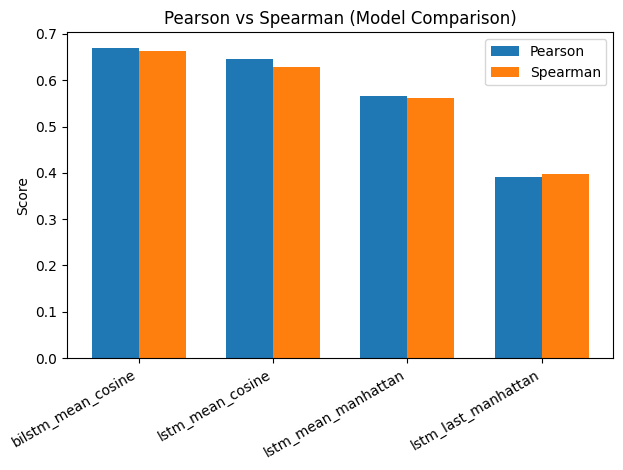

In [30]:
x = range(len(df))
width = 0.35

plt.figure()
plt.bar([i - width/2 for i in x], df["test_pearson"], width=width, label="Pearson")
plt.bar([i + width/2 for i in x], df["test_spearman"], width=width, label="Spearman")

plt.xticks(x, df["name"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Pearson vs Spearman (Model Comparison)")
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
# Asigna una clasificación a cada modelo. Una puntuación más alta equivale a una mejor clasificación.
df["pearson_rank"] = df["test_pearson"].rank(ascending=False)
df["spearman_rank"] = df["test_spearman"].rank(ascending=False)

print(df[["name", "pearson_rank", "spearman_rank"]])


                  name  pearson_rank  spearman_rank
0   bilstm_mean_cosine           1.0            1.0
2     lstm_mean_cosine           2.0            2.0
3  lstm_mean_manhattan           3.0            3.0
1  lstm_last_manhattan           4.0            4.0


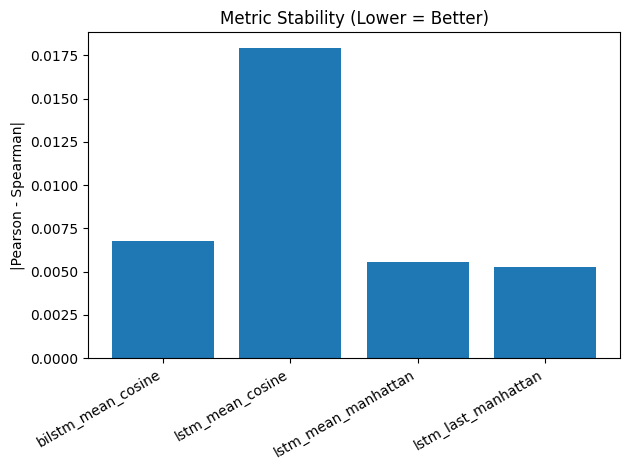

In [32]:
df["gap"] = abs(df["test_pearson"] - df["test_spearman"])

plt.figure()
plt.bar(df["name"], df["gap"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("|Pearson - Spearman|")
plt.title("Metric Stability (Lower = Better)")
plt.tight_layout()
plt.show()


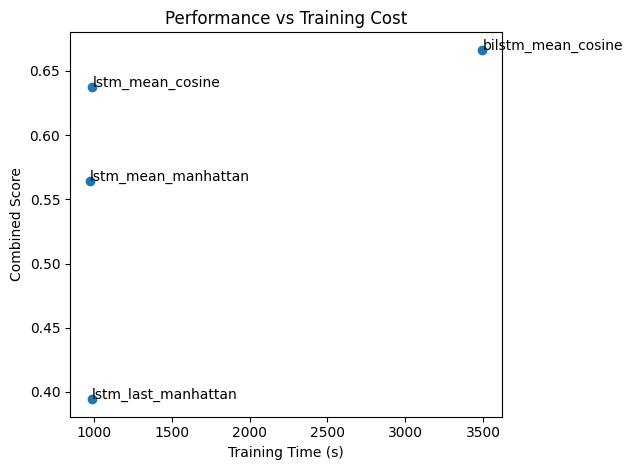

In [33]:
plt.figure()
plt.scatter(df["train_time_s"], df["combined"])

for i, txt in enumerate(df["name"]):
    plt.annotate(txt, (df["train_time_s"].iloc[i], df["combined"].iloc[i]))

plt.xlabel("Training Time (s)")
plt.ylabel("Combined Score")
plt.title("Performance vs Training Cost")
plt.tight_layout()
plt.show()


In [34]:
df["score"] = df["combined"] - df["test_mae"]

df_sorted = df.sort_values("score", ascending=False)

print(df_sorted[["name", "test_pearson", "test_spearman", "test_mae", "score"]])


                  name  test_pearson  test_spearman  test_mae     score
0   bilstm_mean_cosine      0.669886       0.663131  0.199147  0.467362
2     lstm_mean_cosine      0.646398       0.628466  0.206157  0.431275
3  lstm_mean_manhattan      0.566889       0.561309  0.204658  0.359441
1  lstm_last_manhattan      0.391634       0.396877  0.268360  0.125896


,name,n_win,avg_delta
3,lstm_mean_manhattan,5,0.007662
0,bilstm_mean_cosine,6,0.047325
2,lstm_mean_cosine,5,0.049461
1,lstm_last_manhattan,6,0.086354


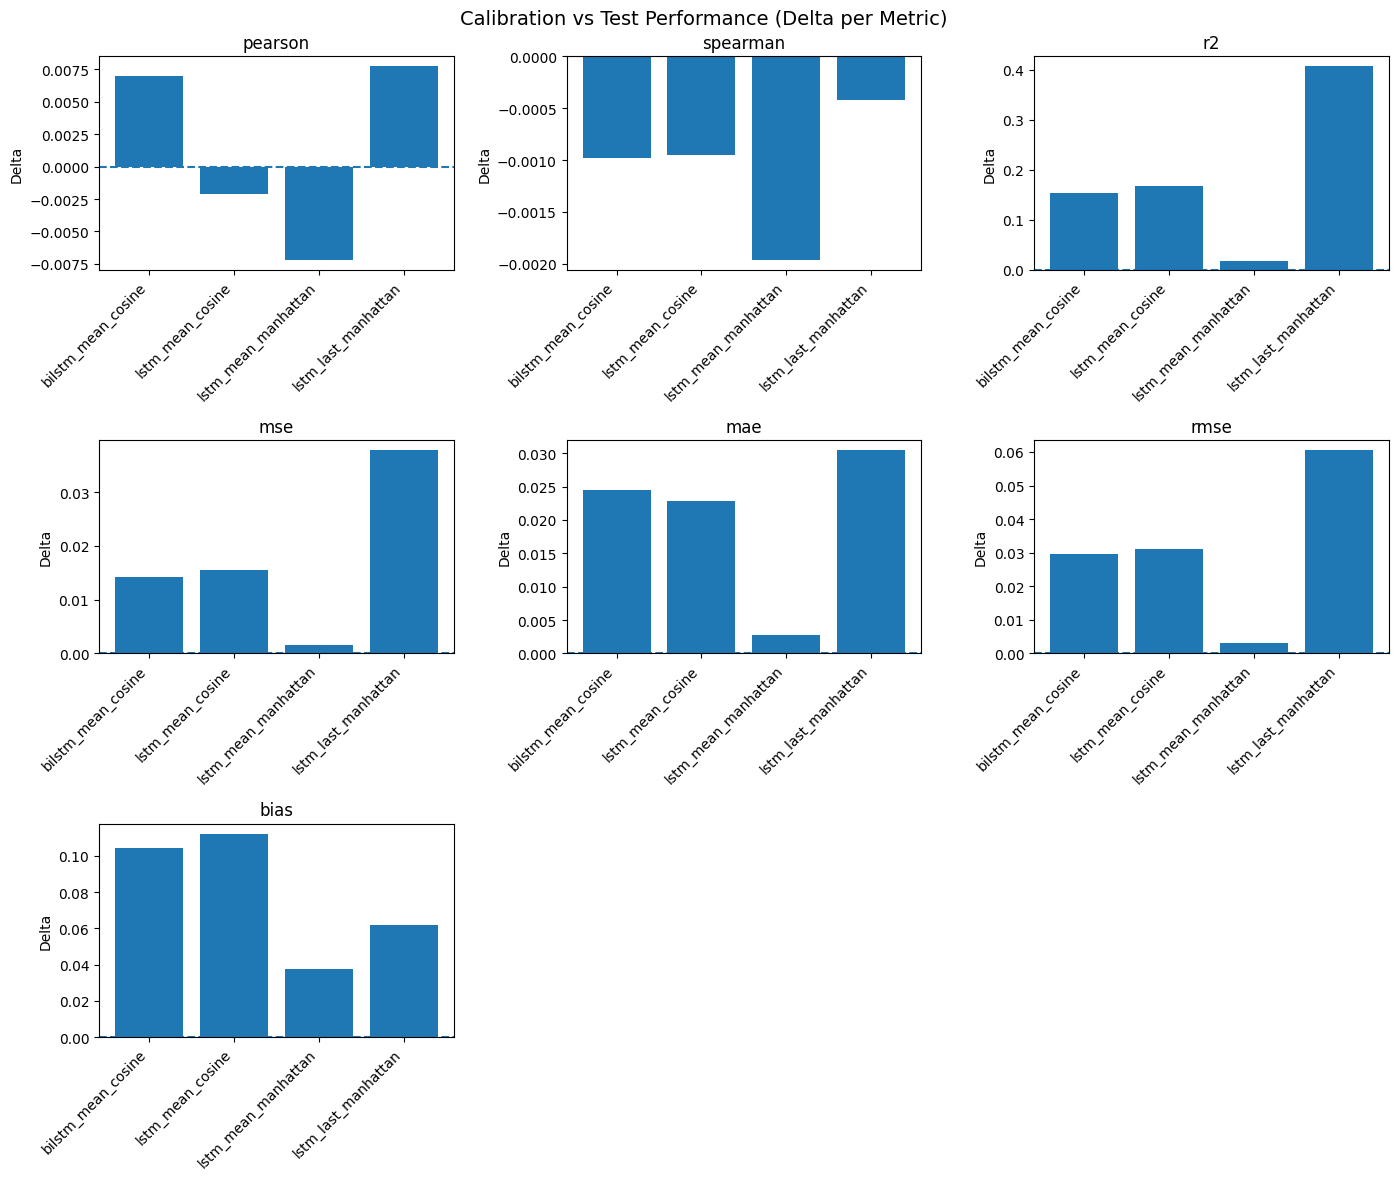

In [54]:
# Más alto --> mejor
pos_metrics = ["pearson", "spearman", "r2"]
# Más bajo --> mejor
neg_metrics = ["mse", "mae", "rmse"]
# Más cerca de 0 --> mejor
special_metrics = ["bias"]

# Cuando la diferencia es positiva, es mejor, de modo que usando calibración para el modelo, mejora ese parámetro.
for metric in pos_metrics:
	df[f"delta_{metric}"] = df[f"calibration_{metric}"] - df[f"test_{metric}"]

for metric in neg_metrics:
	df[f"delta_{metric}"] = df[f"test_{metric}"] - df[f"calibration_{metric}"]

for metric in special_metrics:
	df[f"delta_{metric}"] = abs(df[f"test_{metric}"]) - abs(df[f"calibration_{metric}"])
	
all_metrics = pos_metrics + neg_metrics + special_metrics

for metric in all_metrics:
	df[f"cal_win_{metric}"] = df[f"delta_{metric}"] > 0

df["n_win"] = df[[f"cal_win_{m}" for m in all_metrics]].sum(axis=1)
df["avg_delta"] = df[[f"delta_{m}" for m in all_metrics]].mean(axis=1)
df_ranked = df.sort_values("avg_delta")
display(df_ranked[["name", "n_win", "avg_delta"]])

n_metrics = len(all_metrics)
n_cols = 3
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(all_metrics):
	ax = axes[i]

	ax.bar(df["name"], df[f"delta_{metric}"])
	
	ax.axhline(0, linestyle="--")

	ax.set_title(metric)
	ax.set_ylabel("Delta")

	ax.set_xticks(range(len(df)))
	ax.set_xticklabels(df["name"], rotation=45, ha="right")

for j in range(i + 1, len(axes)):
	fig.delaxes(axes[j])

fig.suptitle("Calibration vs Test Performance (Delta per Metric)", fontsize=14)
plt.tight_layout()
plt.show()
